# Transformer Internals — How the Architecture Actually Works

In [ ]:
# If you are running this on Google Colab, uncomment and run the line below first.
# !pip install -q torch numpy matplotlib

## What we have so far — and what is still missing

In the previous notebooks we covered the building blocks:

- **Tokenization** converts text into numbers
- **Embeddings** give those numbers meaning
- **Attention** lets each word look at context and update its meaning accordingly

But attention alone is not a model. It is one component inside a much larger architecture called the **Transformer**.

Think of it like building a car. You now understand how the engine works (attention). But a car also needs a gearbox, wheels, a frame, fuel injection, and a steering wheel. This notebook covers the other parts — the ones that make attention actually work reliably inside a full model.

The pieces we will look at:

1. **Positional Encoding** — telling the model where each word sits in the sentence
2. **Multi-Head Attention** — running attention multiple times in parallel to capture different relationships
3. **Feed-Forward Network** — processing each word individually after attention
4. **Residual Connections** — a shortcut that helps information flow through deep layers
5. **Layer Normalization** — keeping activations stable so training does not collapse
6. **Stacking it all** — how these pieces combine into one Transformer block, and how blocks stack into a full model

## 1. Positional Encoding — giving words a seat number

Here is a problem attention has. When you feed a sentence in, attention can see every word — but it has no idea what order they appear in.

"Dog bites man" and "Man bites dog" use the exact same words and the exact same embeddings. Without positional information, the model sees them as identical.

**The analogy:** Imagine a cinema where every seat looks identical, and the tickets have no seat numbers. Everyone files in, but nobody knows where to sit. The film crew has no way of knowing who is in row 1 and who is in row 20. Positional encoding is the seat number printed on the ticket — it tells each word exactly where it sits in the sequence.

The original Transformer paper used **sinusoidal positional encoding** — a pattern of sine and cosine waves at different frequencies. Each position gets a unique pattern of numbers that is added to its embedding before attention runs.

Why sine waves? Because they have a useful property — the model can figure out relative distances between positions just by looking at the patterns. Position 5 and position 8 will always have a consistent mathematical relationship, regardless of the total sequence length.

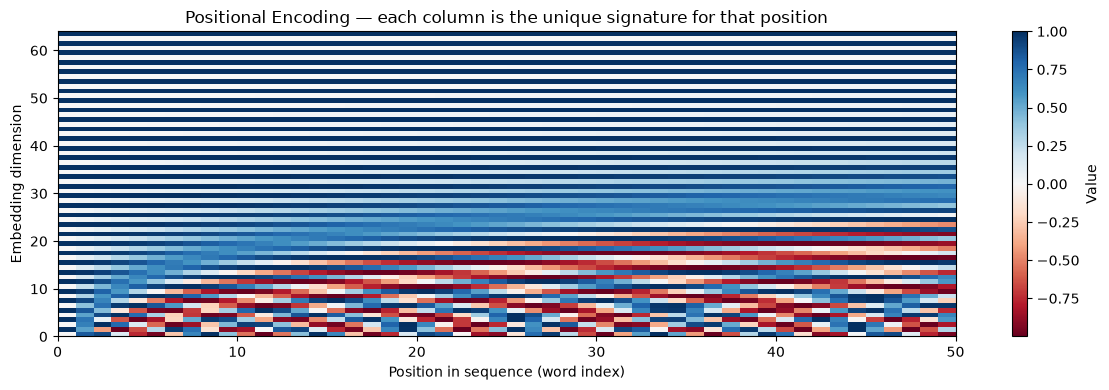

Each column is a unique pattern of numbers added to the word embedding at that position.
No two positions look the same, so the model always knows where each word sits.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(seq_len, d_model):
    pe = np.zeros((seq_len, d_model))
    positions = np.arange(seq_len).reshape(-1, 1)
    dims = np.arange(d_model)

    # Even indices use sine, odd indices use cosine
    angles = positions / np.power(10000, (2 * (dims // 2)) / d_model)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

seq_len = 50
d_model = 64
pe = positional_encoding(seq_len, d_model)

plt.figure(figsize=(12, 4))
plt.pcolormesh(pe.T, cmap='RdBu')
plt.colorbar(label='Value')
plt.xlabel('Position in sequence (word index)')
plt.ylabel('Embedding dimension')
plt.title('Positional Encoding — each column is the unique signature for that position')
plt.tight_layout()
plt.show()

print('Each column is a unique pattern of numbers added to the word embedding at that position.')
print('No two positions look the same, so the model always knows where each word sits.')

## 2. Multi-Head Attention — looking at the sentence from multiple angles

In the previous notebook we ran attention once. But a single pass of attention can only capture one type of relationship at a time.

Consider this sentence: *"The animal did not cross the street because it was too tired."*

There are multiple things a model might want to understand simultaneously:
- What does "it" refer to? (the animal — a coreference relationship)
- Why did it not cross? (because it was tired — a causal relationship)
- What is the subject of the sentence? (the animal — a syntactic relationship)

**The analogy:** Imagine a panel of judges at a cooking competition. One judge evaluates flavour, another evaluates presentation, and a third evaluates creativity. Each judge watches the same dish being made, but focuses on a completely different dimension. Then their scores are combined. Multi-head attention is the same idea — multiple attention "heads" run in parallel, each learning to focus on a different type of relationship. Their outputs are then concatenated and mixed together.

The key insight is that each head gets its own set of Q, K, V weight matrices — so each head genuinely learns to look for something different. One head might learn to track grammatical subjects. Another might track which nouns pronouns refer to. Another might focus on adjacent words.

In [4]:
import numpy as np

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def single_head_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores  = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores)
    return weights @ V

np.random.seed(0)
seq_len = 5
d_model = 8
num_heads = 2
d_head = d_model // num_heads   # each head works on a smaller slice

X = np.random.randn(seq_len, d_model)

head_outputs = []
for h in range(num_heads):
    # Each head has its own weight matrices
    W_q = np.random.randn(d_model, d_head) * 0.3
    W_k = np.random.randn(d_model, d_head) * 0.3
    W_v = np.random.randn(d_model, d_head) * 0.3

    Q = X @ W_q
    K = X @ W_k
    V = X @ W_v

    out = single_head_attention(Q, K, V)
    head_outputs.append(out)
    print(f'Head {h+1} output shape: {out.shape}')

# Concatenate all heads back together
multi_head_output = np.concatenate(head_outputs, axis=-1)
print(f'\nAfter concatenating {num_heads} heads: {multi_head_output.shape}')
print(f'Same shape as input ({seq_len}, {d_model}) — the model dimensions are preserved.')
print('\nEach head looked at the same input from a different angle.')
print('Their outputs are concatenated so all perspectives are kept.')

Head 1 output shape: (5, 4)
Head 2 output shape: (5, 4)

After concatenating 2 heads: (5, 8)
Same shape as input (5, 8) — the model dimensions are preserved.

Each head looked at the same input from a different angle.
Their outputs are concatenated so all perspectives are kept.


## 3. Feed-Forward Network — each word thinks for itself

After multi-head attention, every word now holds a rich, context-aware representation. But there is one more step before we move to the next layer — a **Feed-Forward Network (FFN)**.

The FFN is applied to each word's vector independently — the same set of weights, applied one word at a time. It is not looking at other words. It is just processing each word's updated representation through two linear layers with a non-linear activation in between.

**The analogy:** Imagine a factory assembly line. Attention is the meeting where workers talk to each other and share information. The feed-forward network is what happens after the meeting — each worker goes back to their own workstation and processes what they learned, independently, before the next meeting begins.

The FFN typically expands the dimension first (by a factor of 4) and then projects it back down. This expansion gives the network room to compute more complex transformations before compressing the result back to the original size.

In GPT-2 (768 dimensions), the FFN expands to 3072 dimensions in the middle, then collapses back to 768. That middle layer is where a lot of the model's factual knowledge is thought to be stored.

In [5]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

def feed_forward(x, d_model, d_ff):
    # Two learned weight matrices with a ReLU in between
    W1 = np.random.randn(d_model, d_ff) * 0.1
    b1 = np.zeros(d_ff)
    W2 = np.random.randn(d_ff, d_model) * 0.1
    b2 = np.zeros(d_model)

    hidden = relu(x @ W1 + b1)   # expand
    out    = hidden @ W2 + b2     # compress back
    return out

np.random.seed(1)
seq_len = 5
d_model = 8
d_ff    = d_model * 4   # standard 4x expansion

x   = np.random.randn(seq_len, d_model)
out = feed_forward(x, d_model, d_ff)

print(f'Input shape  : {x.shape}')
print(f'Expanded size: ({seq_len}, {d_ff})  — happens internally')
print(f'Output shape : {out.shape}')
print()
print('The FFN is applied to each of the 5 word vectors separately.')
print(f'Middle layer has {d_ff} dimensions — 4x the original {d_model}.')
print('It expands to give room for complex transformations, then compresses back.')

Input shape  : (5, 8)
Expanded size: (5, 32)  — happens internally
Output shape : (5, 8)

The FFN is applied to each of the 5 word vectors separately.
Middle layer has 32 dimensions — 4x the original 8.
It expands to give room for complex transformations, then compresses back.


## 4. Residual Connections — the shortcut that saves deep networks

A Transformer is not just one attention layer — it is many layers stacked on top of each other. GPT-2 has 12 layers, GPT-3 has 96, GPT-4 has 120. The deeper you go, the harder it becomes to train.

The problem is called the **vanishing gradient**. When you stack many layers, the training signal (the gradient) that flows backwards through the network gets weaker and weaker. By the time it reaches the early layers, it is almost zero — and those layers stop learning.

**The analogy:** Imagine playing a game of telephone across 96 people. By the time the message reaches the first person, it is completely garbled. Residual connections are like a direct phone line — you can whisper the original message straight to the first person, bypassing all 95 people in between.

In practice, a residual connection just adds the input directly to the output of each sublayer:

```
output = sublayer(x) + x
```

That `+ x` is the entire thing. It looks trivially simple, but it was the key insight that made it possible to train very deep networks. The original input always has a direct path forward — gradients can flow backwards through that path without going through the potentially complex sublayer.

In [7]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

def fake_sublayer(x):
    # Simulates a small transformation — in a real model this would be attention or FFN
    W = np.random.randn(x.shape[-1], x.shape[-1]) * 0.1
    return relu(x @ W)

np.random.seed(2)
x = np.random.randn(5, 8)

# Without residual connection
out_plain = fake_sublayer(x)

# With residual connection — add the original input back
out_residual = fake_sublayer(x) + x

print('Without residual connection:')
print(f'  Input mean  : {x.mean():.4f}')
print(f'  Output mean : {out_plain.mean():.4f}')
print(f'  The transformation can move the values significantly.')
print()
print('With residual connection (sublayer output + original input):')
print(f'  Input mean   : {x.mean():.4f}')
print(f'  Output mean  : {out_residual.mean():.4f}')
print(f'  The original signal is preserved. The sublayer only adds on top of it.')
print()
print('This guarantees that even if the sublayer learns nothing useful,')
print('the original information still passes through unchanged.')

Without residual connection:
  Input mean  : -0.2089
  Output mean : 0.1160
  The transformation can move the values significantly.

With residual connection (sublayer output + original input):
  Input mean   : -0.2089
  Output mean  : -0.1061
  The original signal is preserved. The sublayer only adds on top of it.

This guarantees that even if the sublayer learns nothing useful,
the original information still passes through unchanged.


## 5. Layer Normalization — keeping things from going off the rails

As information flows through dozens of layers, the numbers can grow very large or become very small. This makes training unstable — the gradients explode or vanish, and the model either diverges or refuses to learn.

**Layer Normalization** solves this by rescaling the values at each layer so they have a mean of 0 and a standard deviation of 1. Then it applies two learned parameters — scale (γ) and shift (β) — so the model can restore any range it actually needs.

**The analogy:** Think of a music mixing board. Each instrument is recorded at a different volume — drums are loud, a flute is quiet. Before mixing them together, an engineer normalises each track to a consistent level. Layer norm does the same thing for the activations inside the model — it brings every vector back to a consistent scale before passing it to the next layer.

Without it, one feature might have values in the thousands while another has values near zero. Attention and the feed-forward network would pay way too much attention to the large values and almost completely ignore the small ones.

In [8]:
import numpy as np

def layer_norm(x, eps=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    std  = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + eps)   # gamma=1, beta=0 for this demo

np.random.seed(3)

# Simulating activations that have gone haywire across a layer
x = np.array([
    [0.002, 0.001, 5000.0, 0.003, 4800.0, 0.001, 0.004, 5100.0],  # three features dominate
    [1.0,   2.0,   1.5,    1.8,   0.9,    2.1,   1.7,   1.3  ],   # these are balanced
])

x_norm = layer_norm(x)

print('Before Layer Norm:')
for i, row in enumerate(x):
    print(f'  Row {i}: mean={row.mean():.2f},  std={row.std():.2f},  range=[{row.min():.3f}, {row.max():.3f}]')

print('\nAfter Layer Norm:')
for i, row in enumerate(x_norm):
    print(f'  Row {i}: mean={row.mean():.2f},  std={row.std():.2f},  range=[{row.min():.3f}, {row.max():.3f}]')

print()
print('Both rows now have mean ≈ 0 and std ≈ 1.')
print('The chaotic row 0 is tamed. The balanced row 1 is largely unchanged.')
print('Every layer starts from a consistent baseline — training stays stable.')

Before Layer Norm:
  Row 0: mean=1862.50,  std=2405.69,  range=[0.001, 5100.000]
  Row 1: mean=1.54,  std=0.42,  range=[0.900, 2.100]

After Layer Norm:
  Row 0: mean=0.00,  std=1.00,  range=[-0.774, 1.346]
  Row 1: mean=-0.00,  std=1.00,  range=[-1.536, 1.355]

Both rows now have mean ≈ 0 and std ≈ 1.
The chaotic row 0 is tamed. The balanced row 1 is largely unchanged.
Every layer starts from a consistent baseline — training stays stable.


## 6. Putting it all together — one Transformer block

Every component we have covered is one piece of a **Transformer block**. A full model like GPT or BERT is simply many of these blocks stacked on top of each other.

Here is what happens inside a single block, in order:

```
Input
  │
  ├──► Multi-Head Attention ──► + (residual) ──► Layer Norm
  │                                                   │
  └──────────────────────────────────────────────────►│
                                                       │
                                               Feed-Forward Network
                                                       │
                                               + (residual) ──► Layer Norm
                                                       │
                                                    Output
```

The input passes through attention (with a residual skip around it), gets normalised, then passes through the feed-forward network (with another residual skip around it), and gets normalised again. That entire sequence is one block.

**GPT-2 small** stacks 12 of these blocks.
**GPT-3** stacks 96.
**LLaMA 3 70B** stacks 80.

Each block refines the representation a little further — early blocks tend to learn syntax and basic structure, deeper blocks tend to learn semantics and reasoning patterns.

In [10]:
import numpy as np

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def relu(x):
    return np.maximum(0, x)

def layer_norm(x, eps=1e-6):
    mean = x.mean(axis=-1, keepdims=True)
    std  = x.std(axis=-1, keepdims=True)
    return (x - mean) / (std + eps)

def multi_head_attention(x, num_heads):
    seq_len, d_model = x.shape
    d_head = d_model // num_heads
    outputs = []
    for _ in range(num_heads):
        W_q = np.random.randn(d_model, d_head) * 0.1
        W_k = np.random.randn(d_model, d_head) * 0.1
        W_v = np.random.randn(d_model, d_head) * 0.1
        Q, K, V = x @ W_q, x @ W_k, x @ W_v
        scores  = Q @ K.T / np.sqrt(d_head)
        weights = softmax(scores)
        outputs.append(weights @ V)
    return np.concatenate(outputs, axis=-1)

def feed_forward(x, d_ff):
    d_model = x.shape[-1]
    W1 = np.random.randn(d_model, d_ff) * 0.1
    W2 = np.random.randn(d_ff, d_model) * 0.1
    return relu(x @ W1) @ W2

def transformer_block(x, num_heads=2, d_ff_factor=4):
    d_ff = x.shape[-1] * d_ff_factor

    # Sub-layer 1: Multi-Head Attention + residual + layer norm
    attn_out = multi_head_attention(x, num_heads)
    x = layer_norm(x + attn_out)

    # Sub-layer 2: Feed-Forward + residual + layer norm
    ffn_out = feed_forward(x, d_ff)
    x = layer_norm(x + ffn_out)

    return x

np.random.seed(42)
seq_len = 6    # 6 words
d_model = 8    # 8-dimensional embeddings (tiny — real models use 768+)

x = np.random.randn(seq_len, d_model)

print('Passing input through one Transformer block...\n')
print(f'Input  shape: {x.shape}  (6 words × 8 dimensions)')

out = transformer_block(x)
print(f'Output shape: {out.shape}  (same shape — the block refines, not resizes)')
print()
print('The shape never changes. Each block takes the same shape in and returns the same shape out.')
print('This is what makes it easy to stack dozens of blocks — they all speak the same language.')

Passing input through one Transformer block...

Input  shape: (6, 8)  (6 words × 8 dimensions)
Output shape: (6, 8)  (same shape — the block refines, not resizes)

The shape never changes. Each block takes the same shape in and returns the same shape out.
This is what makes it easy to stack dozens of blocks — they all speak the same language.


## Encoder vs Decoder — the two flavours of Transformer

The Transformer was originally designed with two halves:

**Encoder** (BERT, RoBERTa)
- Reads the entire input at once — every word can attend to every other word in both directions
- Best for understanding tasks: classification, named entity recognition, semantic search
- Produces rich embeddings of the input

**Decoder** (GPT, LLaMA, Claude)
- Generates text one token at a time — each new word can only attend to words that came before it (not future words it has not generated yet)
- This restriction is called **causal masking** — the model is prevented from peeking at the future
- Best for generation tasks: writing, chat, code completion

**The analogy:** An encoder is like a book editor who reads the whole manuscript before making any notes. A decoder is like an author writing a novel — they can only see what they have already written, not the pages ahead.

Most modern large language models (GPT-4, LLaMA, Claude) are decoder-only. BERT and its variants are encoder-only. The original Transformer paper used both together for translation — encode the source language, decode into the target language.

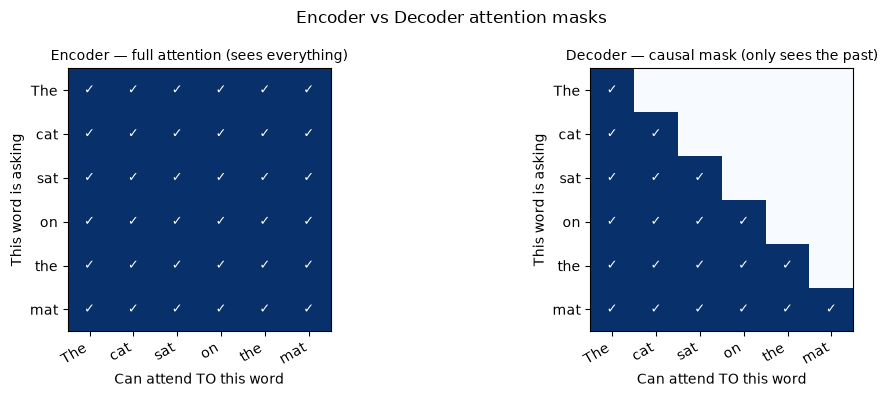

Encoder: every word attends to every other word — full bidirectional context.
Decoder: "mat" cannot see "The", "cat" etc. — it only knows what came before it.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

seq_len = 6
words   = ["The", "cat", "sat", "on", "the", "mat"]

# Encoder mask — every word can see every other word
encoder_mask = np.ones((seq_len, seq_len))

# Decoder mask — each word can only see itself and words before it
decoder_mask = np.tril(np.ones((seq_len, seq_len)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, mask, title in zip(axes,
                           [encoder_mask, decoder_mask],
                           ['Encoder — full attention (sees everything)',
                            'Decoder — causal mask (only sees the past)']):
    ax.imshow(mask, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(words, rotation=30, ha='right')
    ax.set_yticklabels(words)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Can attend TO this word')
    ax.set_ylabel('This word is asking')
    for i in range(seq_len):
        for j in range(seq_len):
            if mask[i, j] == 1:
                ax.text(j, i, '✓', ha='center', va='center', fontsize=9, color='white')

plt.suptitle('Encoder vs Decoder attention masks', fontsize=12)
plt.tight_layout()
plt.show()

print('Encoder: every word attends to every other word — full bidirectional context.')
print('Decoder: "mat" cannot see "The", "cat" etc. — it only knows what came before it.')

## Key takeaways

- **Positional Encoding** adds a unique pattern to each word's embedding so the model knows the order of words in the sequence.
- **Multi-Head Attention** runs attention multiple times in parallel — each head learns to focus on a different type of relationship (grammar, coreference, causality, etc.).
- **Feed-Forward Network** processes each word's representation independently after attention — it is where complex transformations (and a lot of factual knowledge) are stored.
- **Residual Connections** add the input directly to the output of each sublayer — they keep the original signal alive across many layers and prevent gradients from vanishing.
- **Layer Normalization** rescales activations back to a consistent range after each sublayer — it keeps training stable when networks get deep.
- A **Transformer block** combines all five components in sequence. Stacking many blocks is what turns these mechanisms into a powerful language model.
- **Encoders** read everything at once (BERT). **Decoders** generate one token at a time and cannot peek ahead (GPT, LLaMA, Claude).

---

Next up: **Learning Objectives** — now that you know how the architecture works, the next question is: what exactly is it trained to do? The training objective shapes everything about how a model behaves.